In [35]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [36]:
df =pd.read_csv('cleaned_data.csv')

In [37]:
df.head()

,price,kms_driven,owner,age,power,brand
0,35000.0,17654.0,1,3,110.0,8
1,65000.0,16329.0,1,4,180.0,8
2,80000.0,10000.0,1,3,150.0,5
3,53499.0,25000.0,1,6,150.0,5
4,85000.0,8200.0,1,3,160.0,6


In [38]:
x =df.drop('price',axis=1)
y = df['price']

In [39]:
x

,kms_driven,owner,age,power,brand
0,17654.0,1,3,110.0,8
1,16329.0,1,4,180.0,8
2,10000.0,1,3,150.0,5
3,25000.0,1,6,150.0,5
4,8200.0,1,3,160.0,6
...,...,...,...,...,...
17720,32588.0,1,9,150.0,3
17721,14500.0,1,4,250.0,5
17722,6639.0,1,9,180.0,8
17723,20373.0,1,6,220.0,3


In [40]:
y 

0         35000.0
1         65000.0
2         80000.0
3         53499.0
4         85000.0
           ...   
17720     25000.0
17721    123000.0
17722     30000.0
17723     60000.0
17724     22000.0
Name: price, Length: 17725, dtype: float64

In [41]:
x =np.array(x)
y =np.array(y)

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [43]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((14180, 5), (3545, 5), (14180,), (3545,))

In [44]:
# ! pip install tensorflow
# pip install tensorflow
# % pip install tensorflow


In [45]:
import tensorflow as tf
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.models import Sequential

In [46]:
model =Sequential()

In [47]:
input_shape = (5,)

In [48]:
df.head()

,price,kms_driven,owner,age,power,brand
0,35000.0,17654.0,1,3,110.0,8
1,65000.0,16329.0,1,4,180.0,8
2,80000.0,10000.0,1,3,150.0,5
3,53499.0,25000.0,1,6,150.0,5
4,85000.0,8200.0,1,3,160.0,6


<!-- # python -m  venv boss  -->
<!-- activate  -->

In [49]:
# input layer 
model.add(Dense(units=64,activation='relu',input_shape=input_shape))

# dropout layer 
model.add(Dropout(0.2))

# hidden layers
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=16,activation='relu'))
model.add(Dense(units=8,activation='relu')) 


# output layer
model.add(Dense(units=1, activation='linear'))



# back propagation 

model.compile(optimizer='adam',loss='mse',metrics=['mae', 'mse'])




c:\Users\kumaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history =model.fit(x_train,y_train, epochs=10)

Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2199808256.0000 - mae: 36870.6992 - mse: 2199793152.0000
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1309275648.0000 - mae: 26677.8867 - mse: 1309281152.0000
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 375414080.0000 - mae: 14088.5186 - mse: 375410400.0000
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 350385856.0000 - mae: 13536.2080 - mse: 350387424.0000
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 335794624.0000 - mae: 13022.6162 - mse: 335795712.0000
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 322517664.0000 - mae: 12800.7236 - mse: 322519840.0000
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 312371936.0000 - mae: 12586.4141 - mse: 312371584.0000
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 304526112.0000 - mae: 12548.2910 - mse: 304528064.0000
Epoch 9/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 287899712.0000 -

In [52]:
history=pd.DataFrame(history.history)

In [53]:
history

,loss,mae,mse
0,2.101701e+09,35775.902344,2.098347e+09
1,7.974540e+08,20035.363281,7.986892e+08
2,3.664796e+08,13800.280273,3.656664e+08
3,3.473516e+08,13432.786133,3.477012e+08
4,3.298259e+08,12920.263672,3.300653e+08
5,3.211984e+08,12788.899414,3.216819e+08
6,3.126676e+08,12636.914062,3.125853e+08
7,3.056452e+08,12529.773438,3.060766e+08
8,2.946796e+08,12319.915039,2.948453e+08
9,3.009554e+08,12393.507812,2.999989e+08


In [54]:
import matplotlib.pyplot as plt 

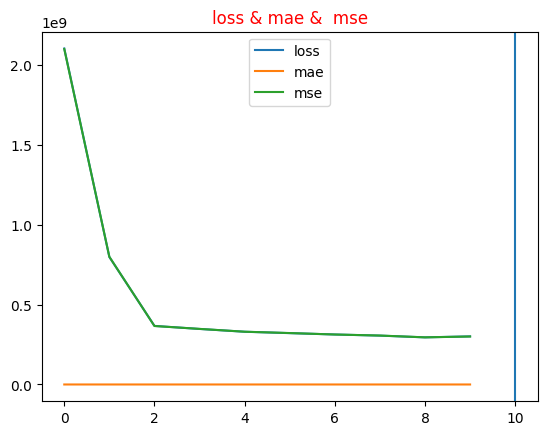

In [55]:
history.plot()
plt.axvline(x=10)
plt.title('loss & mae &  mse',color='red')  
plt.show()
# plt.plot

In [56]:
history =model.fit(x_test,y_test, epochs=10)


Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 311169440.0000 - mae: 12734.2959 - mse: 311170976.0000
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 268966848.0000 - mae: 11815.2900 - mse: 268964832.0000
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 281236320.0000 - mae: 11993.9922 - mse: 281229376.0000
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 276838784.0000 - mae: 11851.6807 - mse: 276838624.0000
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 318908192.0000 - mae: 12605.5479 - mse: 318910464.0000
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 266534752.0000 - mae: 11782.8301 - mse: 266538032.0000
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 267022960.0000 - mae: 11754.8838 - mse: 267027088.0000
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 272148192.0000 - mae: 11795.4834 - mse: 272150976.0000
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 292135584.0000 - mae

In [57]:
history=pd.DataFrame(history.history)

In [ ]:
# pip show tensorflow
# pip un

<Axes: >

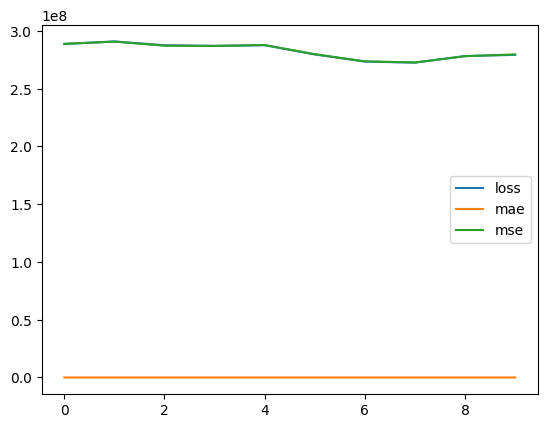

In [58]:
history.plot()

In [59]:
pred = model.predict(x_test)

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [60]:
ouput_data =pd.DataFrame({'Actual':y_test.ravel(),'Predicted':pred.ravel()})

In [61]:
ouput_data

,Actual,Predicted
0,35000.0,40665.777344
1,65000.0,62621.265625
2,22000.0,18782.242188
3,20000.0,21902.347656
4,68000.0,60197.500000
...,...,...
3540,75000.0,72816.476562
3541,55005.0,68672.164062
3542,20000.0,21902.347656
3543,86000.0,69629.851562


In [62]:
ouput_data.describe()

,Actual,Predicted
count,3545.00000,3545.000000
mean,46807.51086,45023.042969
std,27485.60963,21475.800781
min,5800.00000,12582.352539
25%,25000.00000,27166.253906
50%,43000.00000,40665.777344
75%,60000.00000,66040.851562
max,160000.00000,141269.734375


In [63]:
df.describe()

,price,kms_driven,owner,age,power,brand
count,17725.000000,17725.000000,17725.0,17725.000000,17725.000000,17725.000000
mean,46907.235994,27808.819803,1.0,7.838082,169.858956,4.389901
std,27682.509774,19353.607649,0.0,3.341684,40.139959,1.719109
min,5800.000000,22.000000,1.0,1.000000,100.000000,2.000000
25%,25000.000000,11885.000000,1.0,5.000000,150.000000,3.000000
50%,43000.000000,22697.000000,1.0,7.000000,150.000000,3.000000
75%,60000.000000,41939.000000,1.0,9.000000,220.000000,6.000000
max,160700.000000,69415.000000,1.0,17.000000,310.000000,12.000000


In [64]:
model.save('model.h5')